# Wykład 6 — Word Embeddings w praktyce





## Instalacja i import bibliotek

Instalujemy wymagane pakiety, które nie są domyślnie dostępne w Colab.

In [ ]:
!pip install gensim datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 103.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

---
## 1. Pretrenowane embeddingi — Gensim

Gensim oferuje łatwy dostęp do wielu pretrenowanych modeli. Pobieramy model GloVe wytrenowany na korpusie Wikipedia 2014 + Gigaword 5 (100 wymiarów).

In [ ]:
import gensim.downloader as api

# Lista dostępnych modeli
print(list(api.info()['models'].keys()))

# Pobranie modelu (raz — potem cache)
model = api.load("glove-wiki-gigaword-100")

# Rozmiar słownika i wymiar
print(f"Słownik: {len(model)} słów")
print(f"Wymiar wektora: {model.vector_size}")

# Wektor dla słowa
vec = model['python']
print(f"Kształt: {vec.shape}")
print(f"Pierwsze 10 wartości: {vec[:10]}")

vec2 = model['animal']
print(f"Kształt: {vec2.shape}")
print(f"Pierwsze 10 wartości: {vec2[:10]}")

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']
[==================================================] 100.0% 128.1/128.1MB downloaded
Słownik: 400000 słów
Wymiar wektora: 100
Kształt: (100,)
Pierwsze 10 wartości: [ 0.24934    0.68318   -0.044711  -1.3842    -0.0073079  0.651
 -0.33958   -0.19785   -0.33925    0.26691  ]
Kształt: (100,)
Pierwsze 10 wartości: [ 0.55746   0.63049   0.12027  -0.53576   0.14654   0.24643   0.11117
 -0.085524 -0.13056  -0.74412 ]


Każde słowo w pretrenowanym modelu GloVe jest reprezentowane jako wektor 100 liczb zmiennoprzecinkowych (bo załadowaliśmy wariant `glove-wiki-gigaword-100`). Dostęp do tego wektora działa jak w zwykłym słowniku — `model['python']` zwraca tablicę NumPy o kształcie `(100,)`.

Te 100 wartości to współrzędne słowa w przestrzeni semantycznej. Pojedyncza liczba nie ma czytelnej interpretacji (nie odpowiada np. „jest zwierzęciem" czy „jest czasownikiem"), ale łącznie kodują znaczenie — słowa o podobnym sensie mają podobne wektory. Wypisujemy pierwsze 10 wartości po prostu po to, żeby zobaczyć, jak taki wektor wygląda „od środka": to zwykłe liczby rzeczywiste, dodatnie i ujemne.

Modele z GloVe działają na anglojęzycznych korpusach.

---
## 2. Pretrenowane embeddingi — spaCy

spaCy integruje embeddingi bezpośrednio w pipeline NLP. Model md zawiera wstępnie wytrenowane wektory słów (300‑wymiarowe).

In [ ]:
!python -m spacy download en_core_web_md -q
!python -m spacy download pl_core_news_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 86.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 54.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("en_core_web_md")  # 'md' lub 'lg' mają wektory

# Wektor pojedynczego tokena
token = nlp("cat")[0]
print(f"Wektor 'cat': wymiar {token.vector.shape}")
print(f"Przykładowy wektor słowa: {token.vector[:10]}")
print(f"Czy ma wektor: {token.has_vector}")

# Wektor dokumentu = średnia wektorów tokenów
doc = nlp("The cat sat on the mat")
print(f"Wektor dokumentu: wymiar {doc.vector.shape}")
print(f"Przykładowy wektor dokumentu: {doc.vector[:10]}")

# Podobieństwo między dokumentami
doc1 = nlp("I like dogs")
doc2 = nlp("I enjoy cats")
doc3 = nlp("The stock market crashed")
print(f"dogs vs cats: {doc1.similarity(doc2):.3f}")
print(f"dogs vs stock: {doc1.similarity(doc3):.3f}")

Wektor 'cat': wymiar (300,)
Przykładowy wektor słowa: [-0.72483   0.42538   0.025489 -0.39807   0.037463 -0.29811  -0.28279
  0.29333   0.57775   1.2205  ]
Czy ma wektor: True
Wektor dokumentu: wymiar (300,)
Przykładowy wektor dokumentu: [-0.69966835  0.12899633 -0.20060353 -0.09749667  0.06489383 -0.07539502
 -0.23438966  0.11901551 -0.12523101  1.6100234 ]
dogs vs cats: 0.794
dogs vs stock: 0.310


Ten kod demonstruje pracę z **wektorami słów** (word embeddings) w bibliotece spaCy. Najpierw ładowany jest model `en_core_web_md` — wariant "medium", który w odróżnieniu od `sm` zawiera 300-wymiarowe wektory GloVe. Następnie pokazany jest wektor pojedynczego tokena `"cat"` — tablica NumPy o kształcie `(300,)`, wraz z podglądem pierwszych 10 wartości i sprawdzeniem flagi `.has_vector`. Dalej prezentowany jest **wektor dokumentu** dla zdania `"The cat sat on the mat"`, który spaCy oblicza jako średnią arytmetyczną wektorów wszystkich tokenów (stąd ten sam wymiar `(300,)`).  Najważniejsza część to **podobieństwo semantyczne**: metoda `.similarity()` oblicza cosinus kąta między wektorami dwóch dokumentów. Porównanie `"I like dogs"` z `"I enjoy cats"` da wysoki wynik (zdania mówią o tym samym, choć innymi słowami), natomiast porównanie z `"The stock market crashed"` — niski, bo tematy są zupełnie niepowiązane. To ilustruje kluczową właściwość embeddingów: mierzą **bliskość znaczeniową**, nie dosłowne pokrywanie się słów.

In [ ]:
import spacy

nlp = spacy.load("pl_core_news_md")

# Wektor pojedynczego tokena
token = nlp("kot")[0]
print(f"Wektor 'kot': wymiar {token.vector.shape}")
print(f"Przykładowy wektor słowa: {token.vector[:10]}")
print(f"Czy ma wektor: {token.has_vector}")

# Wektor dokumentu = średnia wektorów tokenów
doc = nlp("Kot siedział na macie")
print(f"Wektor dokumentu: wymiar {doc.vector.shape}")
print(f"Przykładowy wektor dokumentu: {doc.vector[:10]}")

# Podobieństwo między dokumentami
doc1 = nlp("Lubię psy")
doc2 = nlp("Uwielbiam koty")
doc3 = nlp("Giełda się załamała")
print(f"psy vs koty: {doc1.similarity(doc2):.3f}")
print(f"psy vs giełda: {doc1.similarity(doc3):.3f}")

Wektor 'kot': wymiar (300,)
Przykładowy wektor słowa: [-6.3031   1.6799   5.5206   2.6071  -2.5904  -0.68184 -4.0832   0.60581
 -0.56431  3.0485 ]
Czy ma wektor: True
Wektor dokumentu: wymiar (300,)
Przykładowy wektor dokumentu: [-1.204495   -0.90274     0.6926001   0.44419247  1.5983276   0.320225
 -0.44326627  1.482535   -2.5855873   1.989725  ]
psy vs koty: 0.857
psy vs giełda: 0.048


---
## 3. Podobieństwo słów — Gensim

Sprawdzamy podobieństwo cosinusowe między słowami oraz wyszukujemy najbliższych sąsiadów i słowa "nie pasujące" do grupy.

In [ ]:
model = api.load("glove-wiki-gigaword-100")

# Najbardziej podobne słowa
similar = model.most_similar("king", topn=10)
for word, score in similar:
    print(f"  {word:15s} {score:.4f}")

# Podobieństwo między dwoma słowami
sim = model.similarity("cat", "dog")
print(f"\nPodobieństwo cat-dog: {sim:.4f}")

sim2 = model.similarity("cat", "car")
print(f"Podobieństwo cat-car: {sim2:.4f}")

# Który nie pasuje?
outlier = model.doesnt_match(["cat", "dog", "fish", "computer"])
print(f"\nNie pasuje: {outlier}")

  prince          0.7682
  queen           0.7508
  son             0.7021
  brother         0.6986
  monarch         0.6978
  throne          0.6920
  kingdom         0.6811
  father          0.6802
  emperor         0.6713
  ii              0.6676

Podobieństwo cat-dog: 0.8798
Podobieństwo cat-car: 0.3110

Nie pasuje: computer


In [ ]:
# Pobieranie wektorów FastText dla polskiego (format tekstowy, skompresowany gzip)
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.pl.300.vec.gz
!gunzip cc.pl.300.vec.gz

In [ ]:
import gensim.downloader as api
from gensim.models import KeyedVectors

model_pl = KeyedVectors.load_word2vec_format("cc.pl.300.vec", limit=100000)

similar = model_pl.most_similar("król", topn=10)
for word, score in similar:
    print(f"  {word:15s} {score:.4f}")

sim = model_pl.similarity("kot", "pies")
print(f"\nPodobieństwo kot-pies: {sim:.4f}")

sim2 = model_pl.similarity("kot", "samochód")
print(f"Podobieństwo kot-samochód: {sim2:.4f}")

outlier = model_pl.doesnt_match(["kot", "pies", "ryba", "komputer"])
print(f"\nNie pasuje: {outlier}")

  Król            0.7705
  władca          0.7488
  książę          0.7329
  monarcha        0.6984
  królem          0.6909
  cesarz          0.6847
  królowa         0.6765
  królowie        0.6632
  króla           0.6393
  Książę          0.6199

Podobieństwo kot-pies: 0.7899
Podobieństwo kot-samochód: 0.3283

Nie pasuje: ryba


---
## 4. Analogie wektorowe — Gensim

Najbardziej znana właściwość embeddingów — **arytmetyka na wektorach**:

$$\vec{król} - \vec{mężczyzna} + \vec{kobieta} \approx \vec{królowa}$$

In [ ]:
# king - man + woman = ?
result = model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)
print("king - man + woman =")
for word, score in result:
    print(f"  {word:15s} {score:.4f}")

# Other analogies
analogies = [
    (["paris", "poland"], ["france"], "capitals"),
    (["bigger", "small"], ["big"], "comparatives"),
    (["walking", "swam"], ["walked"], "verb tense"),
]
for pos, neg, label in analogies:
    res = model.most_similar(positive=pos, negative=neg, topn=1)
    print(f"\n{label}: {res[0][0]} ({res[0][1]:.4f})")

king - man + woman =
  queen           0.7699
  monarch         0.6843
  throne          0.6756
  daughter        0.6595
  princess        0.6521

capitals: warsaw (0.8550)

comparatives: larger (0.8925)

verb tense: swimming (0.7068)


Kod demonstruje **analogie wektorowe** w modelu Word2Vec (obiekt `model` z biblioteki Gensim). Metoda `most_similar` przyjmuje wektory słów z listy `positive`, odejmuje od nich wektory z listy `negative` i zwraca słowa najbliższe wynikowi — w pierwszym przykładzie oblicza *king − man + woman*, co klasycznie daje wynik bliski *queen*, wypisując pięć najlepszych trafień z ich wynikami podobieństwa kosinusowego. Następnie w pętli testowane są trzy dalsze analogie zdefiniowane jako krotki (positive, negative, etykieta): *paris − france + poland* (szukanie stolicy Polski), *bigger − big + small* (forma stopnia wyższego) oraz *walking − walked + swam* (zmiana czasu gramatycznego) — dla każdej wypisywany jest jeden najlepszy wynik, co pokazuje, że relacje semantyczne i gramatyczne są zakodowane jako regularne kierunki w przestrzeni wektorowej embedingów.

In [ ]:
# król - mężczyzna + kobieta = ?
result = model_pl.most_similar(
    positive=["król", "kobieta"],
    negative=["mężczyzna"],
    topn=5
)
print("król - mężczyzna + kobieta =")
for word, score in result:
    print(f"  {word:15s} {score:.4f}")

# Inne analogie
analogies = [
    (["Paryż", "Polska"], ["Francja"], "stolice"),
    (["większy", "mały"], ["duży"], "stopniowanie"),
    (["chodzenie", "pływał"], ["chodził"], "czynność"),
]
for pos, neg, label in analogies:
    try:
        res = model_pl.most_similar(positive=pos, negative=neg, topn=1)
        print(f"\n{label}: {res[0][0]} ({res[0][1]:.4f})")
    except KeyError as e:
        print(f"\n{label}: brak słowa w modelu — {e}")

król - mężczyzna + kobieta =
  królowa         0.7947
  Królowa         0.6459
  Król            0.6086
  królowie        0.5942
  króla           0.5808

stolice: Londyn (0.5770)

stopniowanie: mniejszy (0.7916)

czynność: pływanie (0.6433)


---
## 5. Wizualizacja embeddingów — t-SNE

Redukcja wymiarowości za pomocą t-SNE pozwala zobaczyć, jak embeddingi grupują słowa z tych samych kategorii semantycznych.

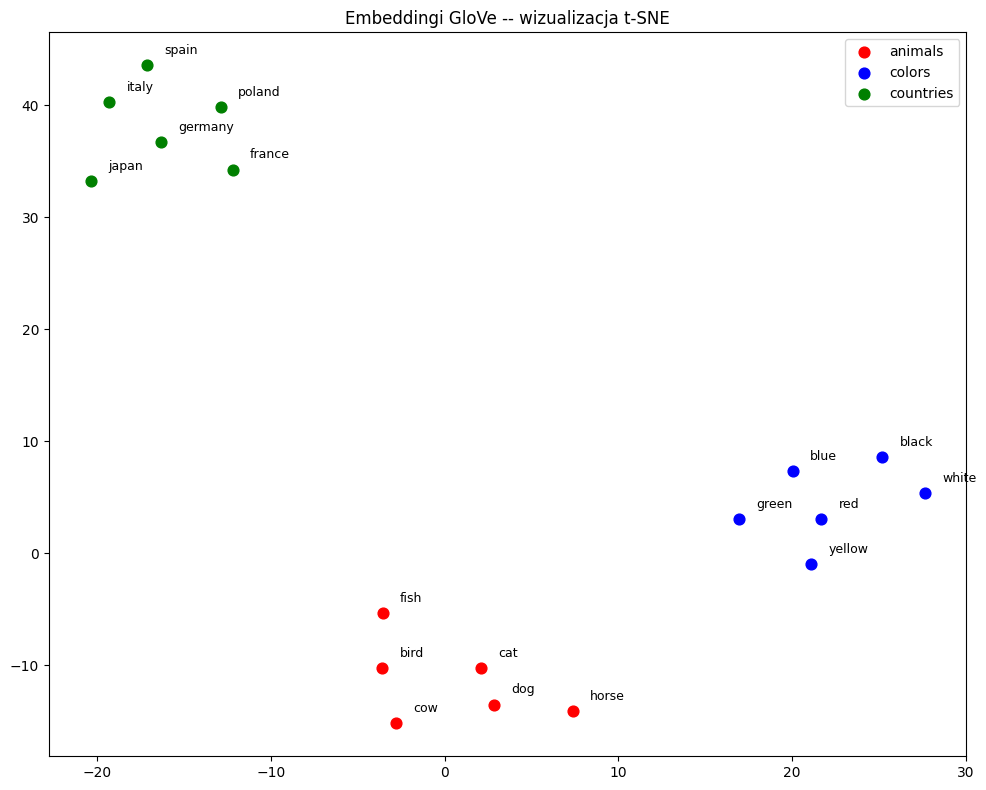

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


# Wybierz grupy słów
groups = {
    "animals": ["cat", "dog", "fish", "bird", "horse", "cow"],
    "colors": ["red", "blue", "green", "yellow", "black", "white"],
    "countries": ["france", "germany", "poland", "italy", "spain", "japan"],
}

words, vectors, labels = [], [], []
for label, group in groups.items():
    for w in group:
        words.append(w)
        vectors.append(model[w])
        labels.append(label)

# t-SNE redukcja do 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(np.array(vectors))

# Rysowanie
fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {"animals": "red", "colors": "blue", "countries": "green"}
plotted_labels = set()

for i, w in enumerate(words):
    group = labels[i]
    ax.scatter(coords[i, 0], coords[i, 1],
               c=colors_map[group], s=60,
               label=group if group not in plotted_labels else "")
    plotted_labels.add(group)
    ax.annotate(w, (coords[i, 0]+1, coords[i, 1]+1), fontsize=9)

ax.legend()
ax.set_title("Embeddingi GloVe -- wizualizacja t-SNE")
plt.tight_layout()
plt.show()

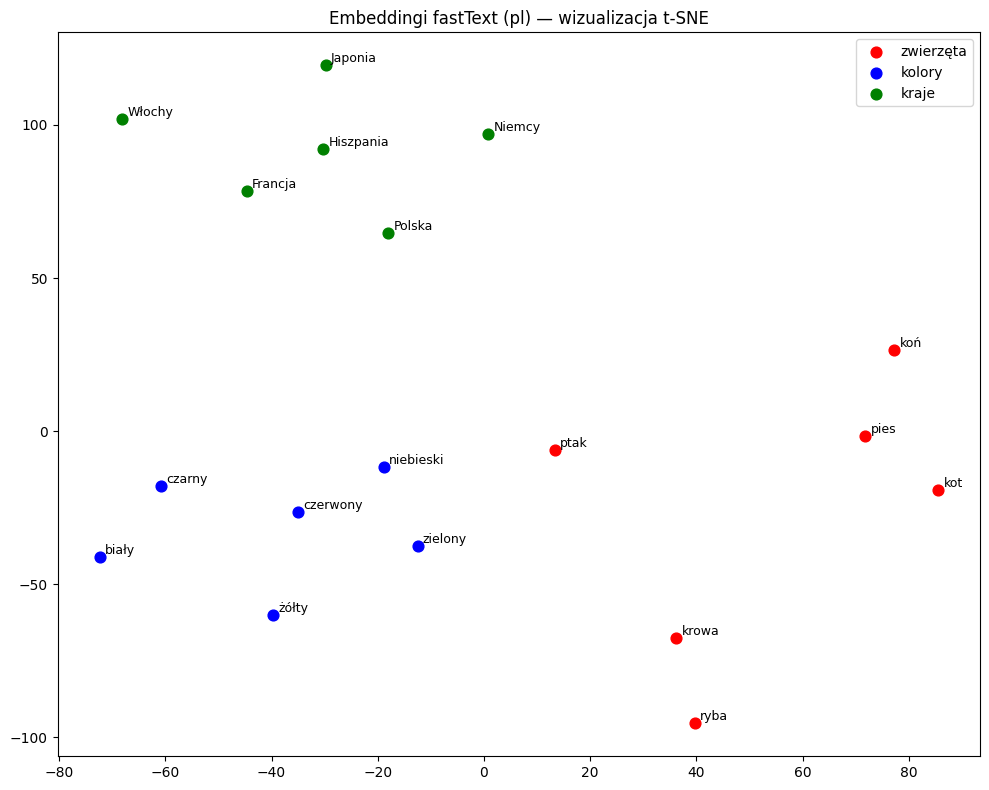

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np


# Wybierz grupy słów
groups = {
    "zwierzęta": ["kot", "pies", "ryba", "ptak", "koń", "krowa"],
    "kolory": ["czerwony", "niebieski", "zielony", "żółty", "czarny", "biały"],
    "kraje": ["Francja", "Niemcy", "Polska", "Włochy", "Hiszpania", "Japonia"],
}

words, vectors, labels = [], [], []
for label, group in groups.items():
    for w in group:
        try:
            vectors.append(model_pl[w])
            words.append(w)
            labels.append(label)
        except KeyError:
            print(f"Brak w modelu: {w}")

# t-SNE redukcja do 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(np.array(vectors))

# Rysowanie
fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {"zwierzęta": "red", "kolory": "blue", "kraje": "green"}
plotted_labels = set()

for i, w in enumerate(words):
    group = labels[i]
    ax.scatter(coords[i, 0], coords[i, 1],
               c=colors_map[group], s=60,
               label=group if group not in plotted_labels else "")
    plotted_labels.add(group)
    ax.annotate(w, (coords[i, 0]+1, coords[i, 1]+1), fontsize=9)

ax.legend()
ax.set_title("Embeddingi fastText (pl) — wizualizacja t-SNE")
plt.tight_layout()
plt.show()

---
## 6. Polskie embeddingi — spaCy

Model `pl_core_news_md` zawiera wektory dla polskich słów. Pozwala to na porównywanie podobieństwa i wyszukiwanie najbliższych sąsiadów w języku polskim.

In [ ]:
!python -m spacy download pl_core_news_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 50.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

nlp = spacy.load("pl_core_news_md")

# Podobieństwo polskich słów
pairs = [
    ("kot", "pies"),
    ("kot", "samochód"),
    ("Warszawa", "Kraków"),
    ("dobry", "zły"),
]
for w1, w2 in pairs:
    t1 = nlp(w1)
    t2 = nlp(w2)
    print(f"{w1:12s} - {w2:12s}: {t1.similarity(t2):.4f}")

for word in nlp.vocab.vectors:
    _ = nlp.vocab[word]

target = nlp("król").vector
sims = []
for word in nlp.vocab:
    if word.has_vector and word.is_alpha and len(word.text) > 1:
        sim = np.dot(target, word.vector) / (
            np.linalg.norm(target) * np.linalg.norm(word.vector) + 1e-8
        )
        sims.append((word.text, sim))

sims.sort(key=lambda x: x[1], reverse=True)
print("Najbliższe do 'król':")
for w, s in sims[1:11]:
    print(f"  {w:15s} {s:.4f}")

kot          - pies        : 0.8419
kot          - samochód    : 0.2527
Warszawa     - Kraków      : 0.7852
dobry        - zły         : 0.6191
Najbliższe do 'król':
  herold          1.0000
  Eochaid         1.0000
  królo           1.0000
  Sułtan          1.0000
  Nabuchodonozor  1.0000
  Selim           1.0000
  Urosz           1.0000
  hetman          1.0000
  Waza            1.0000
  Kisz            1.0000


---
## 7. Trenowanie własnego modelu Word2Vec

### 7.1 Przygotowanie korpusu

Przykładowy mały korpus w języku polskim. Tokenizacja za pomocą `simple_preprocess` z Gensim.

In [ ]:
import re
from gensim.utils import simple_preprocess

# Przykładowy korpus — można zastąpić dowolnym tekstem
corpus_text = """
Uczenie maszynowe to dziedzina sztucznej inteligencji.
Sieci neuronowe są fundamentem głębokiego uczenia.
Przetwarzanie języka naturalnego wykorzystuje modele językowe.
Word embeddings reprezentują słowa jako wektory liczbowe.
Klasyfikacja tekstu to jedno z podstawowych zadań NLP.
Analiza sentymentu pozwala określić wydźwięk opinii.
Transformery zrewolucjonizowały przetwarzanie języka naturalnego.
Tokenizacja to pierwszy krok w przetwarzaniu tekstu.
Modele językowe przewidują następne słowo w sekwencji.
Korpus to zbiór tekstów używany do trenowania modeli.
"""

# Tokenizacja: proste przetwarzanie na listy słów
sentences = [
    simple_preprocess(line)
    for line in corpus_text.strip().split("\n")
    if line.strip()
]

for s in sentences[:3]:
    print(s)

['uczenie', 'maszynowe', 'to', 'dziedzina', 'sztucznej', 'inteligencji']
['sieci', 'neuronowe', 'są', 'fundamentem', 'głębokiego', 'uczenia']
['przetwarzanie', 'języka', 'naturalnego', 'wykorzystuje', 'modele', 'językowe']


### 7.2 Trening modelu Skip-gram

In [ ]:
from gensim.models import Word2Vec

# Trening modelu Skip-gram
model_sg = Word2Vec(
    sentences=sentences,
    vector_size=50,       # wymiar embeddingu (mały bo mały korpus)
    window=3,             # rozmiar okna kontekstowego
    min_count=1,          # minimalna częstość (1 bo mały korpus)
    sg=1,                 # 1 = Skip-gram, 0 = CBOW
    negative=5,           # negative sampling
    epochs=100,           # więcej epok dla małego korpusu
    seed=42,
)

# Wyniki
print(f"Słownik: {len(model_sg.wv)} słów")
print(f"Wymiar: {model_sg.wv.vector_size}")

# Najbliższe słowa
print("\nNajbliższe do 'języka':")
for word, score in model_sg.wv.most_similar("języka", topn=5):
    print(f"  {word:20s} {score:.4f}")

Słownik: 53 słów
Wymiar: 50

Najbliższe do 'języka':
  wykorzystuje         0.3156
  przetwarzaniu        0.2962
  neuronowe            0.2680
  przetwarzanie        0.2587
  słowa                0.2176


---
## 8. Trening na większym polskim korpusie

Pobieramy fragment polskiej Wikipedii za pomocą biblioteki `datasets` (Hugging Face) i trenujemy model Word2Vec na większej ilości danych.

In [ ]:
from datasets import load_dataset

# Załaduj fragment polskiej Wikipedii
ds = load_dataset(
    "wikimedia/wikipedia",
    "20231101.pl",
    split="train[:2000]"  # pierwsze 2000 artykułów
)

# Preprocessing
from gensim.utils import simple_preprocess

sentences_pl = []
for article in ds:
    text = article["text"]
    for line in text.split("\n"):
        tokens = simple_preprocess(line, deacc=False)
        if len(tokens) >= 3:
            sentences_pl.append(tokens)

print(f"Liczba zdań: {len(sentences_pl)}")
print(f"Przykład: {sentences_pl[0][:10]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

20231101.pl/train-00000-of-00006.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

20231101.pl/train-00001-of-00006.parquet:   0%|          | 0.00/339M [00:00<?, ?B/s]

20231101.pl/train-00002-of-00006.parquet:   0%|          | 0.00/274M [00:00<?, ?B/s]

20231101.pl/train-00003-of-00006.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

20231101.pl/train-00004-of-00006.parquet:   0%|          | 0.00/243M [00:00<?, ?B/s]

20231101.pl/train-00005-of-00006.parquet:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1587721 [00:00<?, ? examples/s]

Liczba zdań: 66937
Przykład: ['awk', 'interpretowany', 'język', 'programowania', 'którego', 'główną', 'funkcją', 'jest', 'wyszukiwanie', 'przetwarzanie']


### 8.1 Trening i analiza polskiego modelu

In [ ]:
# Trening modelu na polskim korpusie
model_pl = Word2Vec(
    sentences=sentences_pl,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=10,
    epochs=10,
    workers=4,
    seed=42,
)

print(f"Słownik: {len(model_pl.wv)} słów")

# Analiza wyników
test_words = ["polska", "warszawa", "nauka", "historia", "król"]
for w in test_words:
    if w in model_pl.wv:
        print(f"\nNajbliższe do '{w}':")
        for word, score in model_pl.wv.most_similar(w, topn=5):
            print(f"  {word:20s} {score:.4f}")

Słownik: 42432 słów

Najbliższe do 'polska':
  rosyjska             0.6564
  bułgarska            0.6519
  litewska             0.6484
  autonomiczna         0.6475
  radziecka            0.6462

Najbliższe do 'warszawa':
  wydawnictwo          0.8316
  kraków               0.7773
  poznań               0.7514
  pwn                  0.7268
  wyd                  0.7257

Najbliższe do 'nauka':
  logos                0.7769
  λόγος                0.7562
  biologia             0.7544
  praktyczna           0.7470
  filozoficzna         0.7464

Najbliższe do 'historia':
  ossolineum           0.6247
  starożytność         0.6221
  ziółkowski           0.6211
  bibliografia         0.6148
  universitas          0.6125

Najbliższe do 'król':
  jagiellończyk        0.7737
  waza                 0.7673
  konstantyn           0.7660
  ferdynand            0.7578
  napoleon             0.7508


### 8.2 Zapis i wczytywanie modelu

In [ ]:
from gensim.models import KeyedVectors

# Zapis pełnego modelu (można dotrenować)
model_pl.save("word2vec_pl.model")

# Wczytanie
model_loaded = Word2Vec.load("word2vec_pl.model")

# Zapis tylko wektorów (lżejszy, read-only)
model_pl.wv.save("word2vec_pl.kv")

# Wczytanie samych wektorów
kv = KeyedVectors.load("word2vec_pl.kv")
print(kv.most_similar("polska", topn=3))

# Eksport do formatu tekstowego (kompatybilny z innymi narzędziami)
model_pl.wv.save_word2vec_format("word2vec_pl.txt", binary=False)

[('rosyjska', 0.6564092636108398), ('bułgarska', 0.6519080996513367), ('litewska', 0.6483636498451233)]


### 8.3 Porównanie modeli: CBOW vs Skip-gram

In [ ]:
# Trening CBOW na tych samych danych
model_cbow = Word2Vec(
    sentences=sentences_pl,
    vector_size=100,
    window=5,
    min_count=5,
    sg=0,           # CBOW
    negative=10,
    epochs=10,
    workers=4,
    seed=42,
)

# Porównanie wyników
test_word = "warszawa"
if test_word in model_pl.wv and test_word in model_cbow.wv:
    print("=== Skip-gram ===")
    for w, s in model_pl.wv.most_similar(test_word, topn=5):
        print(f"  {w:20s} {s:.4f}")

    print("\n=== CBOW ===")
    for w, s in model_cbow.wv.most_similar(test_word, topn=5):
        print(f"  {w:20s} {s:.4f}")

=== Skip-gram ===
  wydawnictwo          0.8316
  kraków               0.7773
  poznań               0.7514
  pwn                  0.7268
  wyd                  0.7257

=== CBOW ===
  wydawnictwo          0.9171
  kraków               0.9122
  pwn                  0.8740
  leksykon             0.8654
  wrocław              0.8607


#